# Computing Pairwise Scores for Bulk Data
Now that we know that the distance function works, we'll apply it to pairwise comparisons using the bulk data at 8 Mb. We will compute these comparisons for multiple values of gamma and compare them to scc values and 8 Mb with no tampering.

## Imports

In [71]:
# Enabling Fast Reload 
%load_ext autoreload
%autoreload 2

# Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, dist_weights, get_cool_name, hic_ot_source_to_targets, bin_contact_map

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

# Save directories
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/dist_ot_testing/Bulk'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [18]:
def dist_ot(gamma : int | None = None, res : int = 8):
    '''
        Calculates pairwise OT scores for the bulk data for the given
        gamma value and resolution.

        FUNCTION VERY SPECIFIC TO THIS NOTEBOOK.

        Parameters
        ----------
        gamma : int
            Exponent for the distance weighing function.
            Default = None, does not use distance weighing.
        res : int
            Resolution the data is binned to in Mb.
            Default = 8.
        
        Returns
        -------
        ot_results_df : pd.DataFrame
            Pairwise results of the OT.
    '''
    sample_maps = []
    sample_maps_binned = []

    # Distance weighing
    if gamma is not None:
        for chr1 in chr1s:
            sample_maps.append(dist_weights(chr1, gamma=gamma))
    else:
        sample_maps = chr1s
    
    # Binning
    for sample in sample_maps:
        sample_maps_binned.append(bin_contact_map(sample, res))

    # Performing OT
    ot_results = []
    for sample in sample_maps_binned:
        ot_results.append(hic_ot_source_to_targets(sample, sample_maps_binned, norm='sum'))

    # Converting to dataframe
    ot_results_df = pd.DataFrame(ot_results, index=map_names, columns=map_names)

    # Saving
    ot_results_df.to_csv(f'{save_dir}/dist_weighing_bulk_gamma{gamma}_{res}mb.csv')

    return ot_results_df

def compare_dfs(results1 : pd.DataFrame, results2 : pd.DataFrame, title : str = None,
                xaxis : str = "OT loss", yaxis : str = "OT loss", plot: bool = False):
    ''' 
        Uses OT/scc results dataframes to compare correspondence.

        Parameters
        ----------
        results1 : pd.DataFrame
            Pandas dataframe of ot/scc results.
        results2 : pd.DataFrame
            Pandas dataframe of ot/scc results.
        title : str
            Title for plot.
            Default = None.
        xaxis : str
            Title for x-axis of figure.
            Default = "OT loss"
        yaxis : str
            Title for y-axis of figure.
            Default = "OT loss"
        plot : bool
            Determines if the results are plotted.
            Default = False.
        
        Returns
        -------
        rsqr : float
            R^2 values of the fit.
    '''

    # SCC comparison regression
    results1_flatten = results1.values.flatten()
    results2_flatten = results2.values.flatten()
    regression = linregress(results1_flatten, results2_flatten)
    slope = regression.slope
    intercept = regression.intercept
    rsqr = regression.rvalue**2

    # Plotting SCC comparison
    if plot:
        plt.scatter(results1_flatten, results2_flatten, label="Data")
        plt.plot(results1_flatten, intercept + slope * results1_flatten, color='red',
                label=f'Linear fit (R\u00b2 = {rsqr:.3f})')
        plt.xlabel(xaxis)
        plt.ylabel(yaxis)
        if title is not None:
            plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)

    return rsqr

## Generating Data

### SCC

In [6]:
### Loading data ###
scc_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/mouse_scc_chr1/mouse_chr1_scc.csv'
scc_scores_1mb = pd.read_csv(scc_file, index_col=0)
scc_scores_1mb

,GSE152918_G,GSE152918_MEP,GSE152918_MKP,GSE152918_GMP,GSE152918_MK,GSE152918_MPP,GSE152918_CMP,GSE152918_ST,GSE152918_LT,GSE152918_CLP
GSE152918_G,0.999839,0.694133,0.706921,0.704132,0.729441,0.600578,0.664229,0.644774,0.639193,0.670841
GSE152918_MEP,0.694133,1.000000,0.767096,0.687110,0.672206,0.585597,0.696846,0.656720,0.693530,0.666002
GSE152918_MKP,0.706921,0.767096,1.000000,0.858060,0.800057,0.829800,0.877023,0.908697,0.894721,0.866452
GSE152918_GMP,0.704132,0.687110,0.858060,1.000000,0.770789,0.817004,0.833253,0.856402,0.797286,0.827527
GSE152918_MK,0.729441,0.672206,0.800057,0.770789,0.999838,0.723187,0.760106,0.778881,0.742812,0.732801
GSE152918_MPP,0.600578,0.585597,0.829800,0.817004,0.723187,1.000000,0.807434,0.888482,0.820256,0.833552
GSE152918_CMP,0.664229,0.696846,0.877023,0.833253,0.760106,0.807434,1.000000,0.863406,0.826783,0.819628
GSE152918_ST,0.644774,0.656720,0.908697,0.856402,0.778881,0.888482,0.863406,1.000000,0.897480,0.865503
GSE152918_LT,0.639193,0.693530,0.894721,0.797286,0.742812,0.820256,0.826783,0.897480,1.000000,0.838894
GSE152918_CLP,0.670841,0.666002,0.866452,0.827527,0.732801,0.833552,0.819628,0.865503,0.838894,1.000000


### 8 Mb

In [65]:
### Generating data ###
gamma_8mb = np.array([
    None, 0.25, 0.5, 0.75, 
    1.0, 1.25, 1.5, 
    2.0, 3.0, 4.0
    ])

ot_results_8mb = []

for g in gamma_8mb:
    ot_results_8mb.append(dist_ot(gamma=g, res=8))

In [13]:
ot_results_8mb_dict = {}
for g, map in zip(gamma_8mb, ot_results_8mb):
    ot_results_8mb_dict[g] = map

## Generating r^2 Values

### 8 Mb

#### Graphs

np.float64(0.675021908027818)

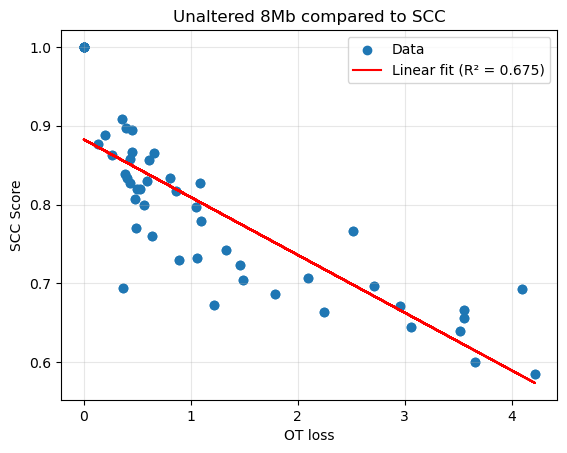

In [ ]:
### SCC to Default
compare_dfs(ot_results_8mb_dict[None], scc_scores_1mb, title="Unaltered 8Mb compared to SCC", yaxis="SCC Score", plot=True)

np.float64(0.6463134159623988)

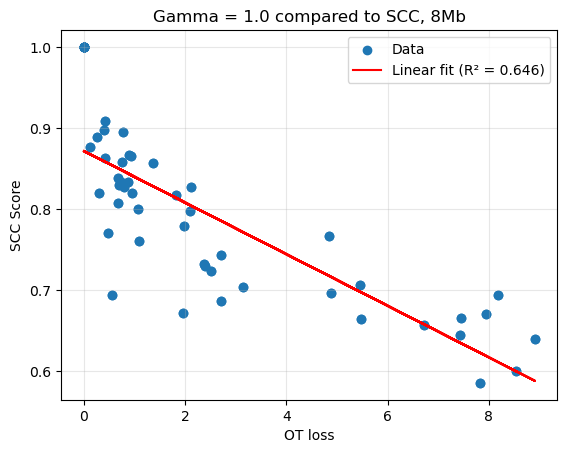

In [24]:
### SCC to gamma = 1.0
compare_dfs(ot_results_8mb_dict[1.0], scc_scores_1mb, title="Gamma = 1.0 compared to SCC, 8Mb", yaxis="SCC Score", plot=True)

np.float64(0.9588005996626222)

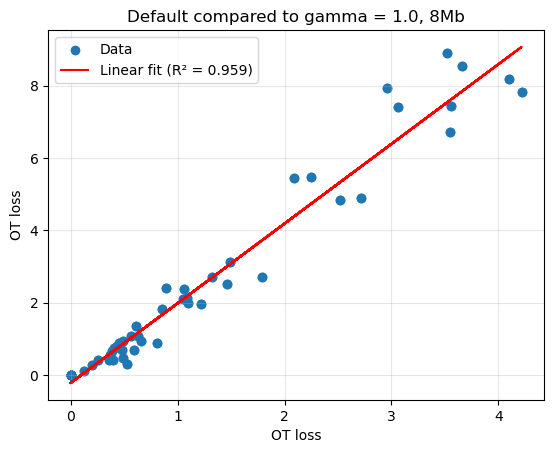

In [23]:
### Default to gamma = 1.0
compare_dfs(ot_results_8mb_dict[None], ot_results_8mb_dict[1.0], title="Default compared to gamma = 1.0, 8Mb", plot=True)

#### All comparisons

In [69]:
# Prepping final DF
datasets = [result.copy() for result in ot_results_8mb]
datasets.append(scc_scores_1mb.copy())
names = ["Default"]
for g in gamma_8mb[1:]:
    names.append(f"γ={g}")
names.append("SCC")

# Comparisons
comparisons_matrix = []

for data in datasets:
    # Empty list to append later
    comparisons = []

    # Compare to all other datasets
    for target in datasets:
        comparisons.append(compare_dfs(data, target))
    
    comparisons_matrix.append(comparisons)

# Generating df
comparisons_df = pd.DataFrame(comparisons_matrix, index=names, columns=names)
comparisons_df

,Default,γ=0.25,γ=0.5,γ=0.75,γ=1.0,γ=1.25,γ=1.5,γ=2.0,γ=3.0,γ=4.0,SCC
Default,1.000000,0.995729,0.987197,0.975250,0.958801,0.936250,0.906637,0.824686,0.611651,0.435861,0.675022
γ=0.25,0.995729,1.000000,0.997544,0.990680,0.978878,0.960807,0.935494,0.861218,0.655802,0.478521,0.663102
γ=0.5,0.987197,0.997544,1.000000,0.997702,0.990401,0.976912,0.956190,0.890611,0.695856,0.519743,0.656123
γ=0.75,0.975250,0.990680,0.997702,1.000000,0.997457,0.988975,0.973394,0.917889,0.736789,0.563876,0.651139
γ=1.0,0.958801,0.978878,0.990401,0.997457,1.000000,0.996995,0.987144,0.943170,0.778894,0.611319,0.646313
γ=1.25,0.936250,0.960807,0.976912,0.988975,0.996995,1.000000,0.996543,0.965770,0.822030,0.662382,0.640198
γ=1.5,0.906637,0.935494,0.956190,0.973394,0.987144,0.996543,1.000000,0.983869,0.864319,0.715488,0.631583
γ=2.0,0.824686,0.861218,0.890611,0.917889,0.943170,0.965770,0.983869,1.000000,0.938516,0.820412,0.603629
γ=3.0,0.611651,0.655802,0.695856,0.736789,0.778894,0.822030,0.864319,0.938516,1.000000,0.964489,0.514378
γ=4.0,0.435861,0.478521,0.519743,0.563876,0.611319,0.662382,0.715488,0.820412,0.964489,1.000000,0.431767


## Overview Figures

### 8 Mb

Text(0.5, 1.0, 'OT Loss Across Gamma Values (8 Mb)')

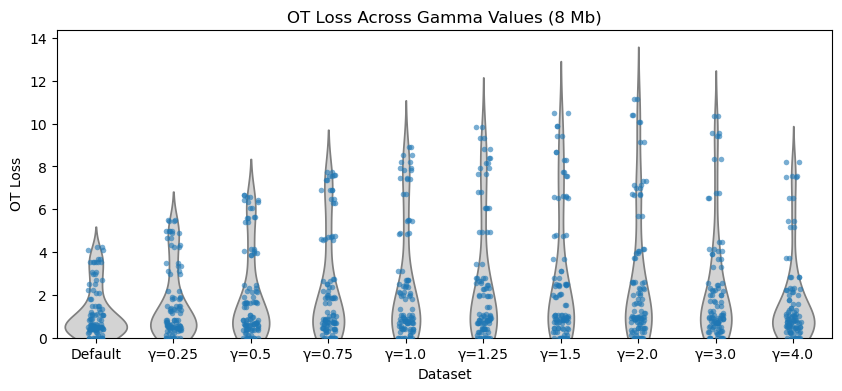

In [78]:
### OT loss default compared to gamma values, distribution ###
    # Converting to long format
long_data = pd.concat(
    [
        pd.DataFrame({
            "value": map.to_numpy().ravel(),
            "dataset": name
        })
        for map, name in zip(ot_results_8mb, names)
    ],
    ignore_index=True
)

    # Creating plot
plt.figure(figsize=(10, 4))

sns.stripplot(
    data=long_data,
    x="dataset",
    y="value",
    jitter=True,
    alpha=0.6,
    size=4
)

sns.violinplot(
    data=long_data,
    x="dataset",
    y="value",
    inner=None,
    color="lightgray"
)

plt.ylim(bottom=0)
plt.ylabel("OT Loss")
plt.xlabel("Dataset")
plt.title("OT Loss Across Gamma Values (8 Mb)")

Text(0, 0.5, 'r² compared to default 8Mb')

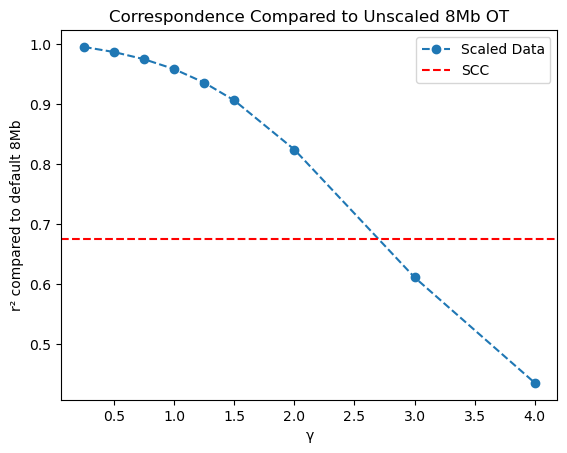

In [96]:
### OT loss default compared to gamma values, r^2 ###
default_r2 = comparisons_df["Default"].iloc[1:-1]
scc_default = comparisons_df["Default"]["SCC"]

plt.plot(gamma_8mb[1:], default_r2, marker="o", linestyle="--", label="Scaled Data")
plt.axhline(scc_default, color="red", linestyle="--", label="SCC")
plt.title("Correspondence Compared to Unscaled 8Mb OT")
plt.legend()
plt.xlabel("γ")
plt.ylabel("r\u00b2 compared to default 8Mb")

Text(0, 0.5, 'r² compared to SCC')

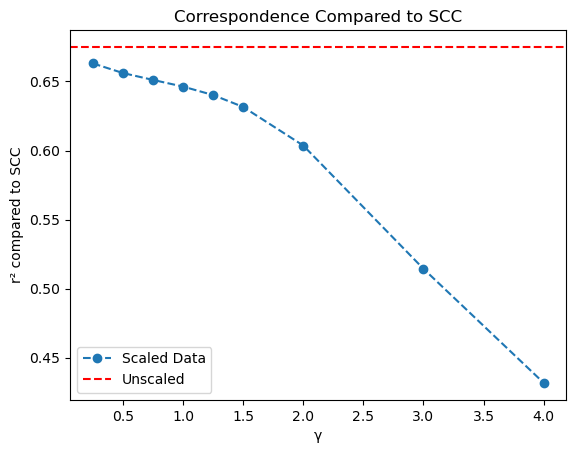

In [97]:
### SCC compared to gamma values, r^2 ###
scc_r2 = comparisons_df["SCC"].iloc[1:-1]

plt.plot(gamma_8mb[1:], scc_r2, marker="o", linestyle="--", label="Scaled Data")
plt.axhline(scc_default, color="red", linestyle="--", label="Unscaled")
plt.title("Correspondence Compared to SCC")
plt.legend()
plt.xlabel("γ")
plt.ylabel("r\u00b2 compared to SCC")

Text(0.5, 1.0, 'Heatmap of Correspondence Between OT on Scaled Data/SCC')

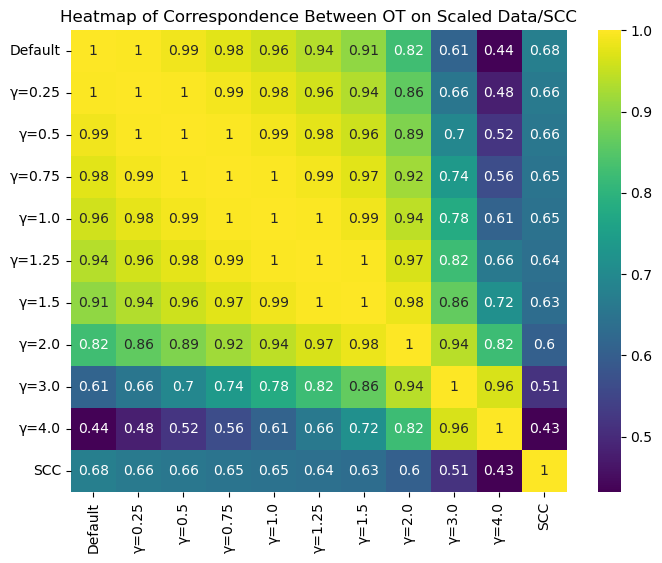

In [95]:
### Heatmap ###
plt.figure(figsize=(8, 6))
sns.heatmap(comparisons_df, annot=True, cmap="viridis")
plt.title("Heatmap of Correspondence Between OT on Scaled Data/SCC")